# Do Tech Stocks Move Together? (2015-2026)
### Investigating Market Concentration Risk & Diversification Limits in Tech-Heavy Portfolios

---
Project was completed with 2 team members
---

**Stocks Under Analysis:** Apple (`AAPL`), Microsoft (`MSFT`), NVIDIA (`NVDA`) and Amazon (`AMZN`)

**Training Period:** January 2015 - December 2025  
**Testing Period:** January 2026 - Present

---

## Section 1 - Project Objectives & Rationale

### Why are we doing this?

The primary goal of this project is to investigate the phenomenon of market concentration risk within the technology sector by analyzing the price movements of four major "Big Tech" stocks: Apple (`AAPL`), Microsoft (`MSFT`), NVIDIA (`NVDA`) and Amazon (`AMZN`).

In recent years, these companies have come to represent a disproportionate share of major stock indices (like the S&P 500). If these stocks move in high correlation, meaning they rise and fall together, it suggests that "diversifying" a portfolio by holding multiple tech giants might offer a false sense of security. 

By modeling their historical returns (2015–2025) and forecasting their performance in 2026 using both traditional statistical methods (ARIMA) and machine learning (XGBoost), we aim to determine the extent to which these stocks are tethered to each other and what that means for investors seeking true diversification.

## Section 2 - Environment Setup & Imports

**Goal:** Ensuring the computing environment has all the necessary tools and mathematical libraries required for data retrieval, manipulation, visualization, and advanced predictive modeling.

In [1]:
# Data extraction
import yfinance as yf

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ARIMA
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ML modeling
!pip install xgboost
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statistical tests
import scipy
from scipy.stats import shapiro, normaltest, jarque_bera

# Style preferences
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize":(14, 6),
    "figure.dpi":120,
    "axes.titlesize":14,
    "axes.labelsize":12,
    "xtick.labelsize":10,
    "ytick.labelsize":10,
    "legend.fontsize":10,
    "lines.linewidth":1.8,
    "axes.spines.top":False,
    "axes.spines.right": False,
})

## Section 3 - Data Extraction & Pipeline

**Goal:** Building a reusable Python data pipeline using `yfinance` to download adjusted closing prices for all four stocks.

**Process:** We define our list of tickers and date ranges as variables. We then loop through each ticker, using the `yf.download` function to pull data from Yahoo Finance. These individual stock series are then merged into a single "Master" DataFrame indexed by date.

In [2]:
from datetime import date 

# Tickers List and Date Range Variables
tickers=["AAPL", "MSFT", "NVDA", "AMZN"]
train_start="2015-01-01"
train_end="2025-12-31"
test_start="2026-01-01"
test_end=str(date.today())

# Adjusting Close Prices using yfinance
frames={}
for ticker in tickers:
    df = yf.download(ticker, start=train_start, end=test_end, auto_adjust=True, progress=False)
    if df.empty:
        print(f"[WARNING] No data returned for {ticker}")
        continue
    df.columns = df.columns.get_level_values(0)
    frames[ticker]=df["Close"]

# Merge into single dataframe 
prices=pd.DataFrame(frames)
prices.index=pd.to_datetime(prices.index)
prices.index.name="Date"

In [3]:
# Inspecting the Data
print("First 5 Trading Days (2015)")
print(prices.head())

print(f"\nLast 5 Trading Days (until {date.today().strftime('%B %d, %Y')})")
print(prices.tail())

print("\nSummary Statistics (2015–2026)")
print(prices.describe())

First 5 Trading Days (2015)
                 AAPL       MSFT      NVDA     AMZN
Date                                               
2015-01-02  24.214893  39.767689  0.482985  15.4260
2015-01-05  23.532726  39.401989  0.474828  15.1095
2015-01-06  23.534929  38.823677  0.460432  14.7645
2015-01-07  23.864948  39.316940  0.459232  14.9210
2015-01-08  24.781893  40.473557  0.476507  15.0230

Last 5 Trading Days (until April 18, 2026)
                  AAPL        MSFT        NVDA        AMZN
Date                                                      
2026-04-13  259.200012  384.369995  189.309998  239.889999
2026-04-14  258.829987  393.109985  196.509995  249.020004
2026-04-15  266.429993  411.220001  198.869995  248.500000
2026-04-16  263.399994  420.260010  198.350006  249.699997
2026-04-17  270.230011  422.790009  201.679993  250.559998

Summary Statistics (2015–2026)
              AAPL         MSFT         NVDA         AMZN
count  2839.000000  2839.000000  2839.000000  2839.000000
mea

**Results & Interpretation:** 

The output displays the "head" and "tail" of our dataset. We can see the massive growth over time, for example, NVIDIA (`NVDA`) trading at roughly 0.48 dollars in early 2015 compared to over 180 dollars in early 2026. The summary statistics show the mean prices and volatility (standard deviation), providing a baseline of how these stocks have behaved over the last 11 years.

## Section 4 - Data Cleaning & Log Return Transformation

**Goal:** Raw stock prices are often "non-stationary" (they have a trend), which makes them difficult to model statistically. We transform prices into log returns to stabilize the mean over time. We also perform an Augmented Dickey-Fuller (ADF) test to mathematically prove that the data is stationary.

**Process:** We use `ffill()` to handle any missing data points (like holidays) and then apply the natural log of the price ratio  ($ln(P_t / P_{t-1})$). The `adfuller` function is then run on each stock's return series.

In [4]:
# Checking for missing values and handling them
prices_clean = prices.ffill().dropna()

# Computing log returns: log_return = ln(P_t / P_{t-1})
log_return = np.log(prices_clean / prices_clean.shift(1)).dropna()

In [5]:
# ADF test and summary table
adf_results = {}
for ticker in tickers:
    result = adfuller(log_return[ticker].dropna())
    adf_results[ticker] = {
        "ADF Statistic" : round(result[0], 4),
        "p-value"       : round(result[1], 6),
        "Critical (1%)" : round(result[4]["1%"], 4),
        "Critical (5%)" : round(result[4]["5%"], 4),
        "Critical (10%)": round(result[4]["10%"], 4),
    }

adf_table = pd.DataFrame(adf_results).T
print(adf_table.to_string())

      ADF Statistic  p-value  Critical (1%)  Critical (5%)  Critical (10%)
AAPL       -17.2337      0.0        -3.4327        -2.8626         -2.5673
MSFT       -18.1337      0.0        -3.4327        -2.8626         -2.5673
NVDA       -19.0609      0.0        -3.4327        -2.8626         -2.5673
AMZN       -53.7804      0.0        -3.4327        -2.8626         -2.5673


In [6]:
# Splitting into train and test sets
log_returns_train = log_return.loc[train_start:train_end]
log_returns_test  = log_return.loc[test_start:test_end]

**Results & Interpretation:** 

The ADF table shows p-values of 0.0 for all stocks. Since the p-values are significantly lower than 0.05, we reject the null hypothesis of a unit root. This confirms our log returns are stationary, meaning they are now suitable for time-series modeling like ARIMA as ARIMA models assume that the statistical properties of the series are stable over time.

## Section 5 - Exploratory Data Analysis (EDA)

**Goal:** Visualizing the data allows us to spot patterns that statistics might miss, such as "volatility clustering" (where high-volatility days follow each other) or extreme outliers (market crashes or booms).

**Process:** We use `matplotlib` and `seaborn` to create time-series plots of the prices and returns. We also use histograms with Kernel Density Estimation (KDE) to see if the returns follow a normal distribution (the "Bell Curve").

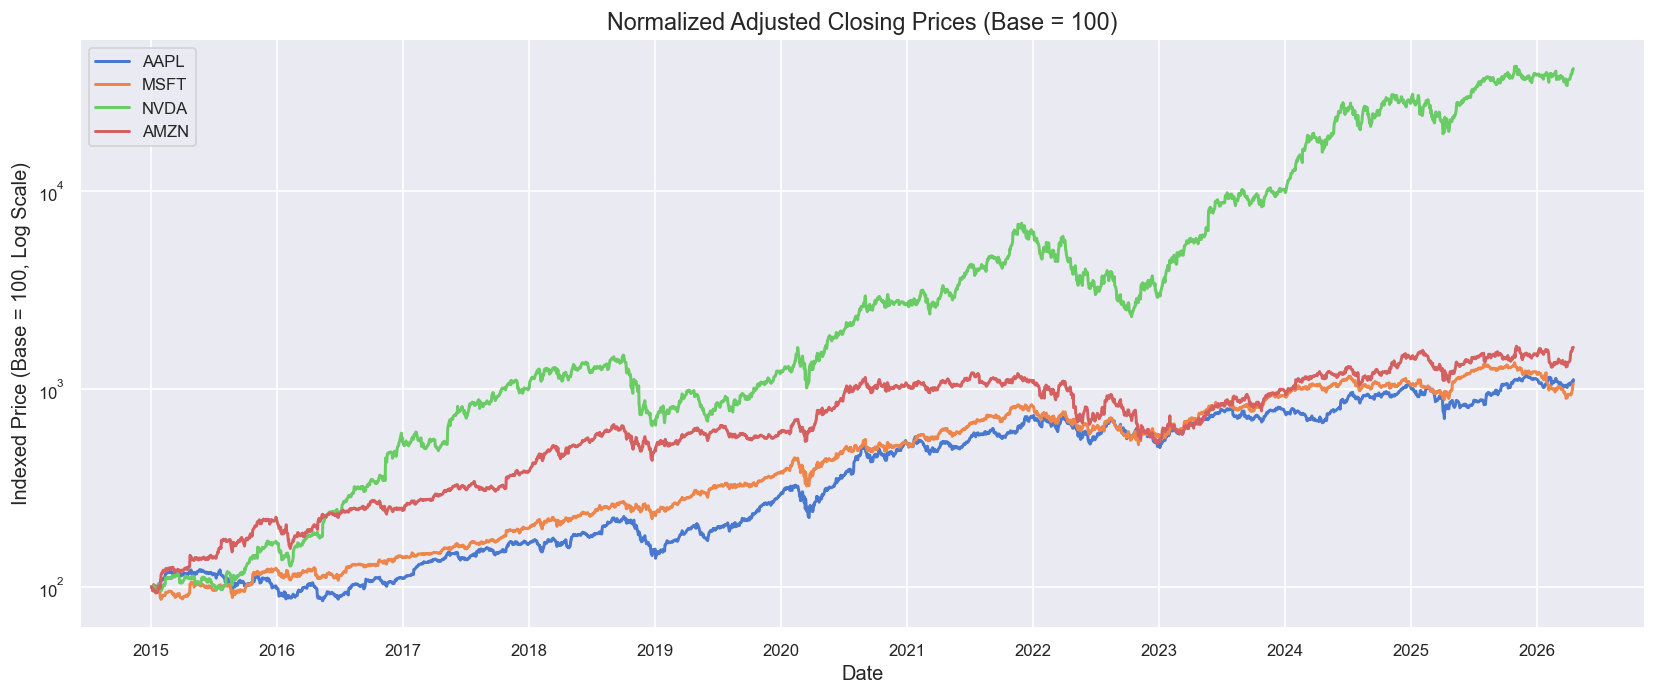

In [7]:
# Plotting normalized price series with base 100 (all 4 stocks)
normalized = prices_clean / prices_clean.iloc[0] * 100 

plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(normalized.index, normalized[ticker], label=ticker)
plt.title("Normalized Adjusted Closing Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Base = 100, Log Scale)")
plt.yscale("log")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.legend()
plt.tight_layout()
plt.show()

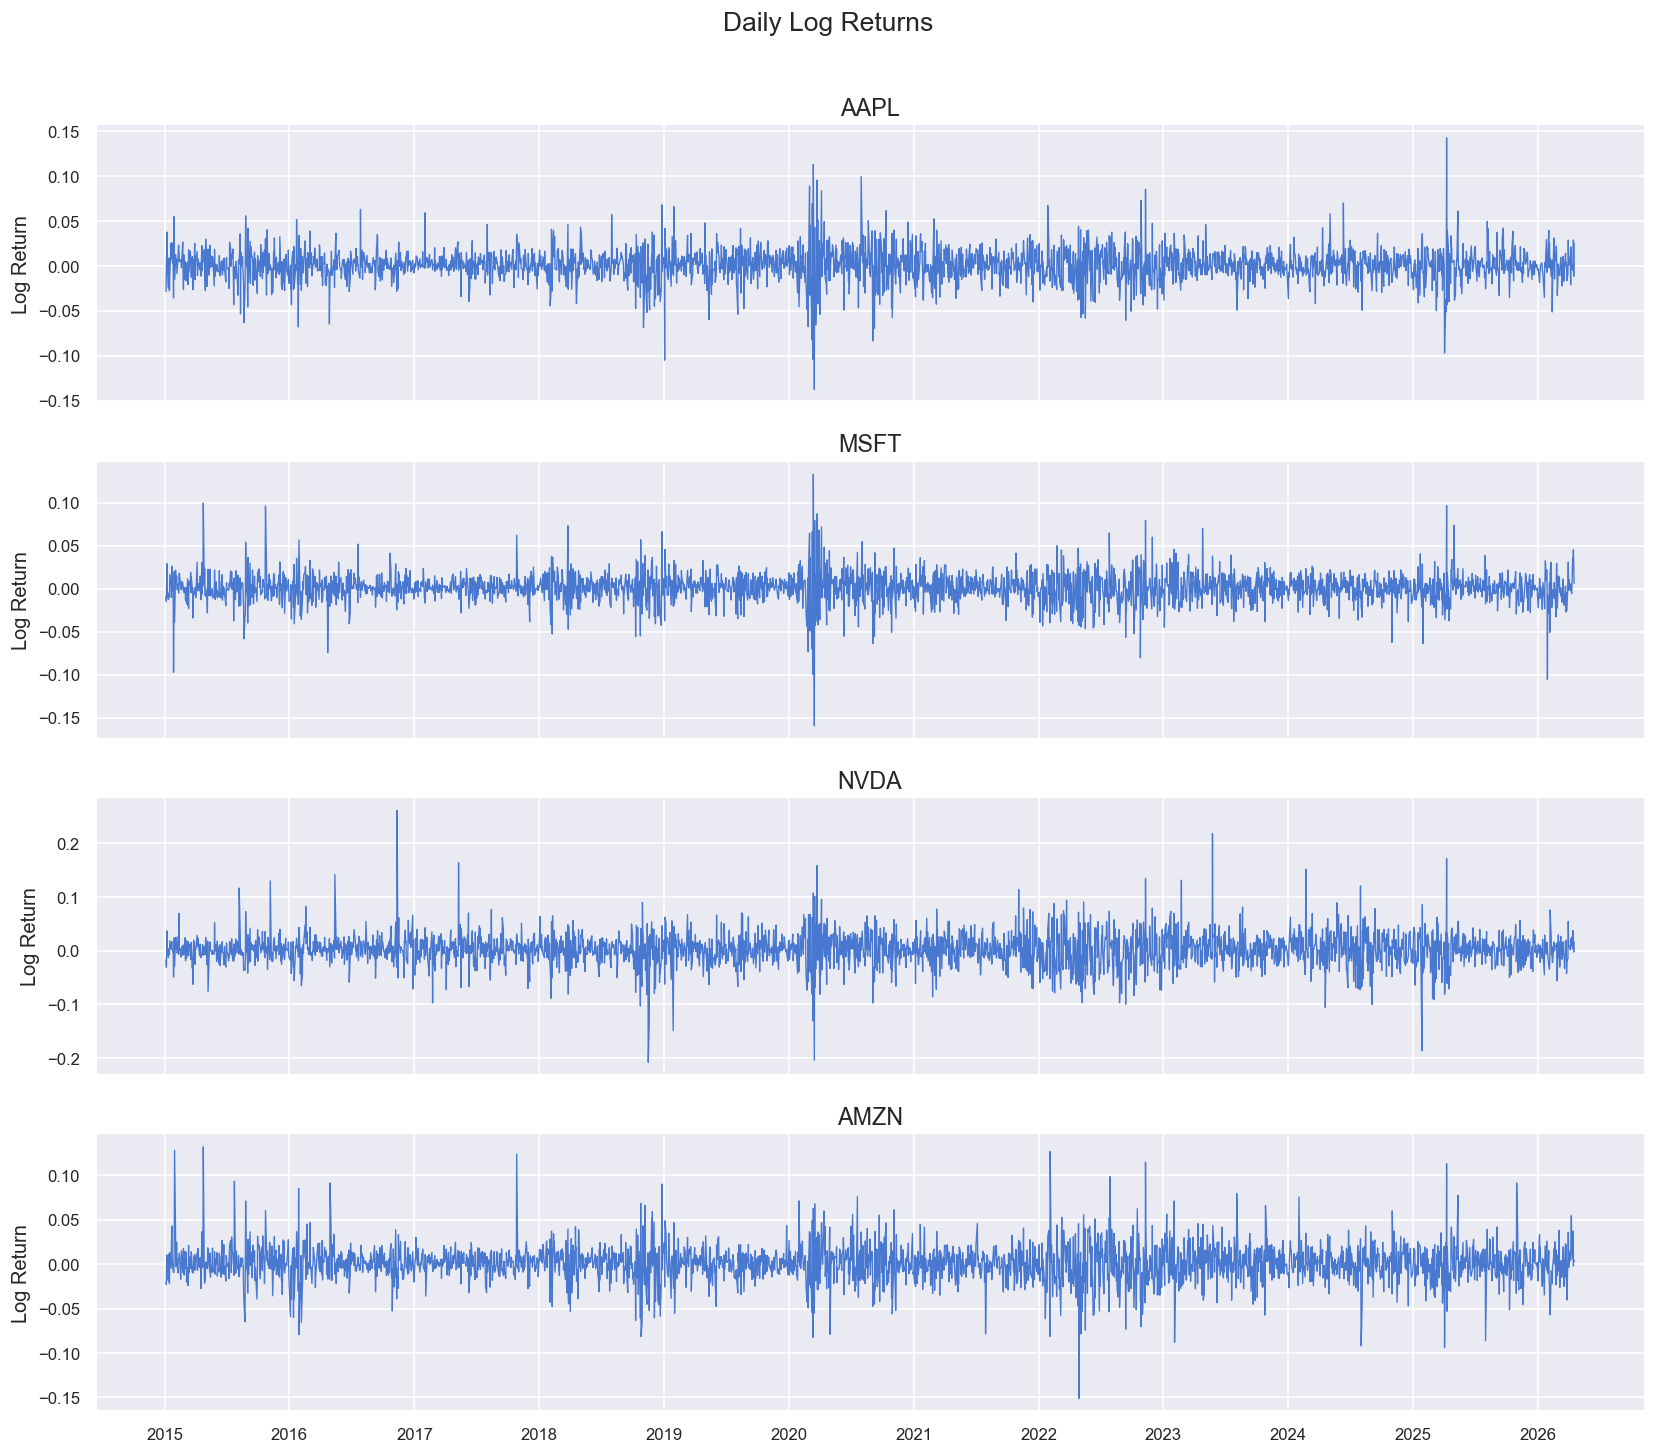

In [8]:
# Plotting log returns time series (subplots per stock)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(log_return.index, log_return[ticker], linewidth=0.8)
    ax.set_title(ticker)
    ax.set_ylabel("Log Return")

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Daily Log Returns", y=1.01)
plt.tight_layout()
plt.show()

          Mean       Std  Skewness       Min       Max
AAPL  0.000874  0.018154 -0.089036 -0.137708  0.142617
MSFT  0.000903  0.016921 -0.096645 -0.159453  0.132929
NVDA  0.002154  0.030464  0.135872 -0.207712  0.260876
AMZN  0.000979  0.020664  0.171567 -0.151398  0.132178


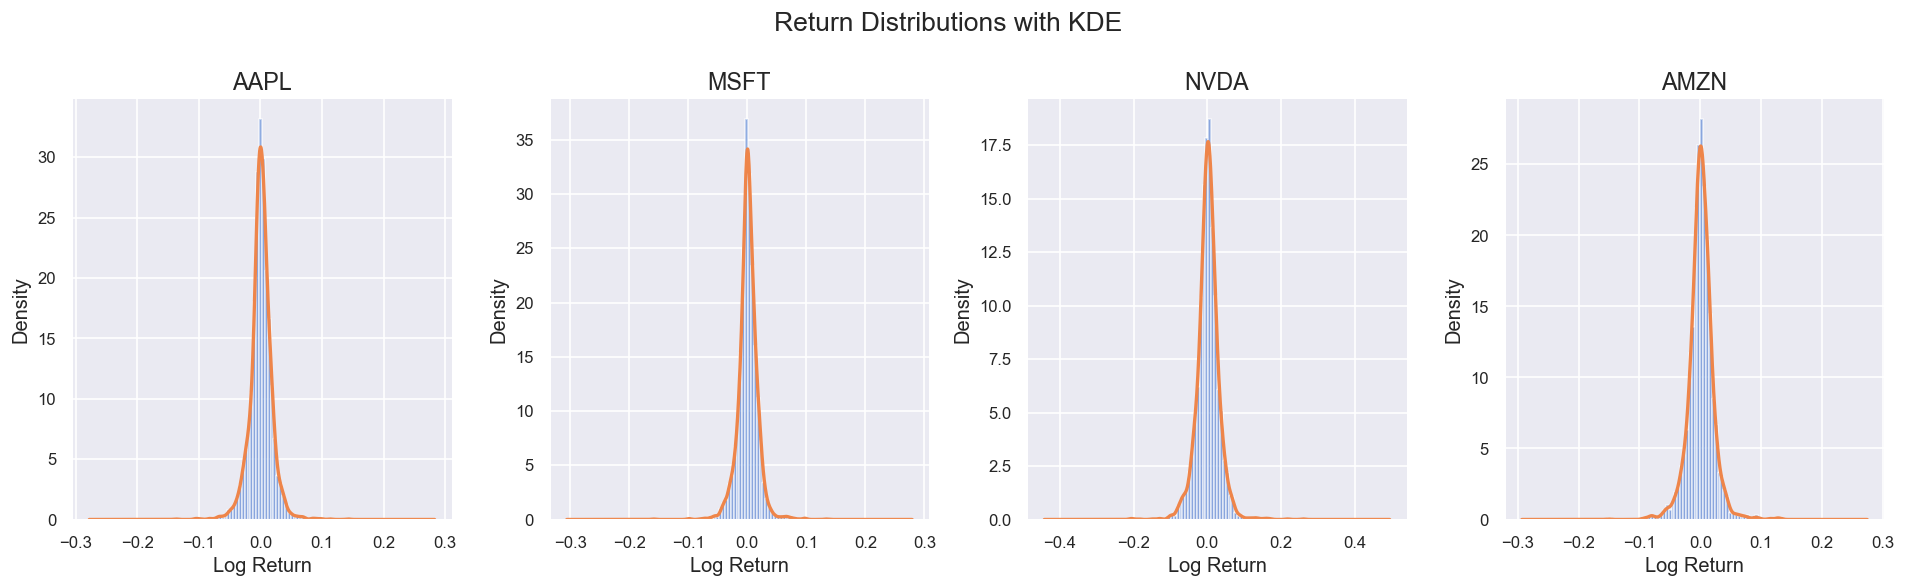

In [9]:
# Computing summary statistics table (mean, std, skew)
stats_table = pd.DataFrame({
    "Mean"    : log_returns_train.mean(),
    "Std"     : log_returns_train.std(),
    "Skewness": log_returns_train.skew(),
    "Min"     : log_returns_train.min(),
    "Max"     : log_returns_train.max(),
})
print(stats_table.round(6))

# Ploting return distributions with histogram + KDE
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, ticker in zip(axes, tickers):
    log_returns_train[ticker].hist(bins=60, density=True, alpha=0.6, ax=ax)
    log_returns_train[ticker].plot.kde(ax=ax, linewidth=2)
    ax.set_title(ticker)
    ax.set_xlabel("Log Return")

plt.suptitle("Return Distributions with KDE")
plt.tight_layout()
plt.show()

**Results & Interpretation:**

- **Price Plot:** Shows the dramatic, non-linear growth of tech stocks, particularly the "AI boom" surge in NVIDIA.

- **Return Distributions:** The histograms likely show "fat tails" (kurtosis, having higher probabilities of extreme outcomes), meaning extreme price swings happen more often than a standard normal distribution would predict. This highlights the inherent risk in tech-heavy portfolios.

**Overall Observed Patterns:**


- **Volatility Clustering:** All four stocks show clearly wider return spikes around 2020 (COVID crash), confirming that large movements cluster together in time. NVDA shows a second distinct clustering  period around 2022 coinciding with the crypto/chip cycle downturn, and again in 2024–2025 during  the AI boom.

- **Asymmetry:** AAPL and MSFT show slight negative skewness (-0.089, -0.097), meaning large negative returns are slightly more frequent. NVDA and AMZN show positive skewness (0.136, 0.172), suggesting occasional large upside moves, consistent with NVDA's extraordinary growth visible in the normalized price chart.

- **Volatility Differences:** NVDA's standard deviation (0.030) is nearly double that of MSFT (0.017), making it significantly riskier on a daily basis. This is clearly visible in the wider x-axis range of NVDA's KDE plot (-0.4 to +0.4) compared to the others (-0.3 to +0.3).

## Section 6 - Correlation Analysis

**Goal:** This is the core of our "Market Concentration" inquiry. If the correlation between these stocks is high (close to 1.0), it proves they move in lockstep, increasing the risk for investors who hold all of them.

**Process:** We calculate the Pearson correlation matrix for the log returns and visualize it using a "Heatmap." This mathematical approach quantifies the linear relationship between every pair of stocks in our portfolio.

In [10]:
# Computing Pearson correlation matrices

corr = log_returns_train.corr()
print("Correlation Matrix:")
print(corr.round(3))

Correlation Matrix:
       AAPL   MSFT   NVDA   AMZN
AAPL  1.000  0.665  0.533  0.558
MSFT  0.665  1.000  0.610  0.652
NVDA  0.533  0.610  1.000  0.523
AMZN  0.558  0.652  0.523  1.000


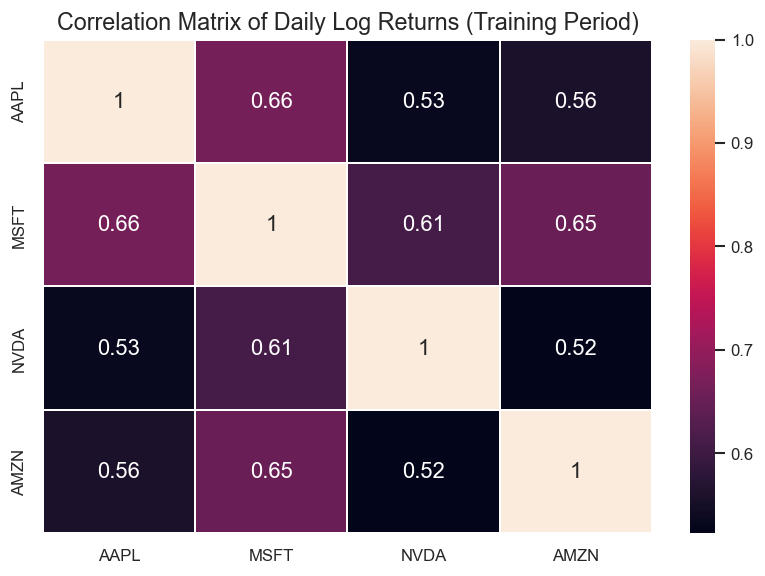

In [11]:
# Plotting annotated heatmap for correlation matrix

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot = True, linewidths = 1, linecolor = "white")
plt.title("Correlation Matrix of Daily Log Returns (Training Period)")
plt.tight_layout()
plt.show()

**Results & Interpretation:**

The heatmap revealed the "co-movement" of these giants. High values between AAPL, MSFT, and NVDA suggest that a single piece of news affecting the tech sector (like interest rate changes) hits all of them similarly, limiting the benefits of holding multiple different tech stocks. This confirms that these stocks essentially "move together."

## Section 7 - Linear Regression Modeling

**Goal:** We use Linear Regression to determine how much the movement of one stock (the independent variable) can explain the movement of another (the dependent variable). This helps us understand the beta (sensitivity) of these stocks relative to each other.

**Process:** Using `statsmodels`, we define a feature (e.g., MSFT returns) to predict a target (e.g., AAPL returns). We then look at the $R^2$ score and the coefficient to measure the strength of this predictive relationship.

In [12]:
# Fitting OLS (Ordinary Least Squares) regression for each of the 6 pairwise combinations
# Printing regression summary for each

pairs = [
    ("AAPL", "MSFT"),
    ("AAPL", "NVDA"),
    ("AAPL", "AMZN"),
    ("MSFT", "NVDA"),
    ("MSFT", "AMZN"),
    ("NVDA", "AMZN"),
]

results = []

for stock_a, stock_b in pairs:
    model = smf.ols(f"{stock_a} ~ {stock_b}", data = log_returns_train).fit()
    print(f"\n{stock_a} ~ {stock_b}")
    print(f"  R²        : {model.rsquared:.4f}")
    print(f"  Beta      : {model.params[stock_b]:.4f}")

    results.append({
        "Pair"     : f"{stock_a} ~ {stock_b}",
        "R²"       : round(model.rsquared, 4),
        "Beta"     : round(model.params[stock_b], 4)
    })


AAPL ~ MSFT
  R²        : 0.4420
  Beta      : 0.7132

AAPL ~ NVDA
  R²        : 0.2837
  Beta      : 0.3174

AAPL ~ AMZN
  R²        : 0.3110
  Beta      : 0.4899

MSFT ~ NVDA
  R²        : 0.3724
  Beta      : 0.3390

MSFT ~ AMZN
  R²        : 0.4256
  Beta      : 0.5342

NVDA ~ AMZN
  R²        : 0.2731
  Beta      : 0.7705


**Note:**

- **R² (R-squared):** Proportion of variance in the dependent variable explained by the model.

- **Coefficient (β/Beta):** The expected change in the dependent variable for a one-unit increase in the predictor, holding others constant.

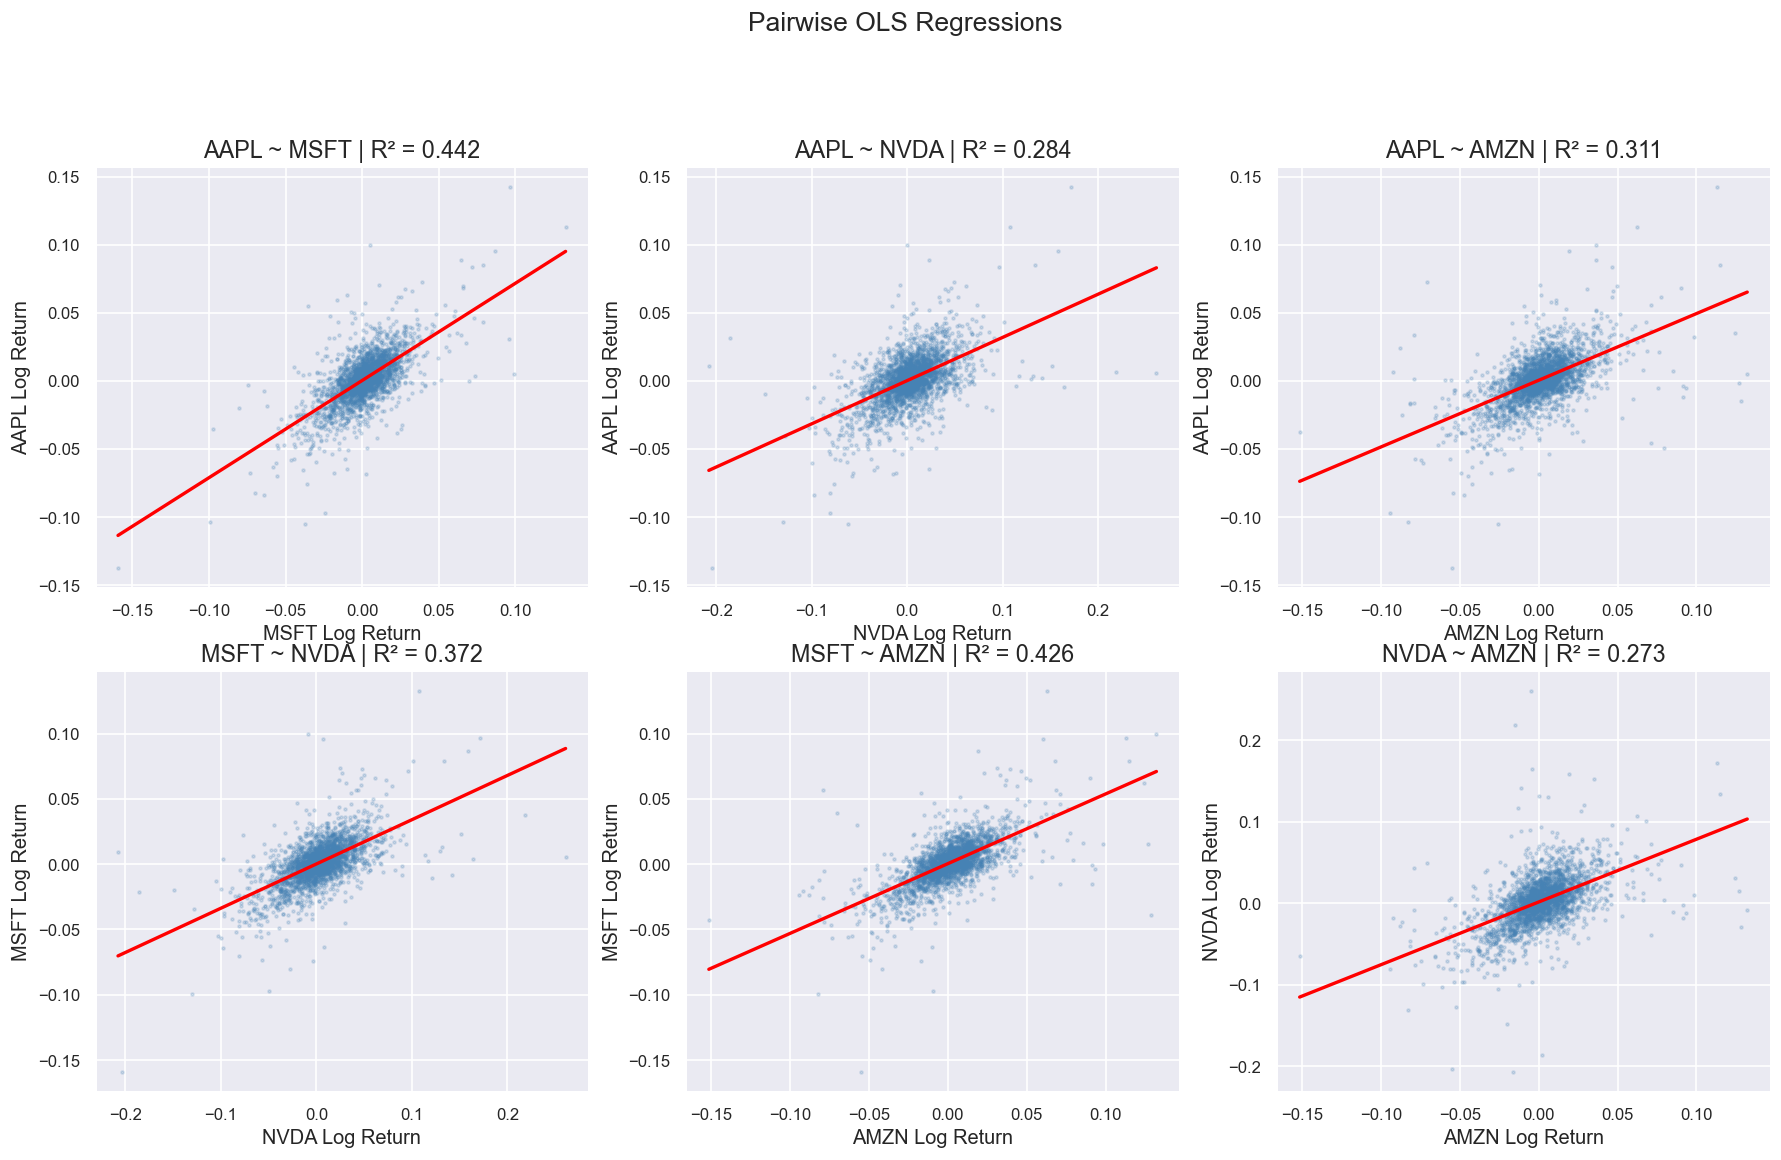

In [13]:
# Plotting the scatter + regression line for each pair

fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.flatten()

for i, (stock_a, stock_b) in enumerate(pairs):
    model  = smf.ols(f"{stock_a} ~ {stock_b}", data=log_returns_train).fit()

    x = log_returns_train[stock_b]
    y = log_returns_train[stock_a]
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.params["Intercept"] + model.params[stock_b] * x_line

    axes[i].scatter(x, y, alpha = 0.2, s = 3, color = "steelblue")
    axes[i].plot(x_line, y_line, color = "red", linewidth = 2)
    axes[i].set_title(f"{stock_a} ~ {stock_b} | R² = {model.rsquared:.3f}")
    axes[i].set_xlabel(f"{stock_b} Log Return")
    axes[i].set_ylabel(f"{stock_a} Log Return")

plt.suptitle("Pairwise OLS Regressions", y = 1.01)
plt.show()

In [14]:
# Multiple regression — each stock regressed on the other three

# AAPL
y = log_returns_train["AAPL"]
X = log_returns_train[["MSFT", "NVDA", "AMZN"]]
X = sm.add_constant(X)
model_aapl = sm.OLS(y, X).fit()
print("\nAAPL ~ MSFT + NVDA + AMZN")
print(f"  R² : {model_aapl.rsquared:.4f}")

# MSFT
y = log_returns_train["MSFT"]
X = log_returns_train[["AAPL", "NVDA", "AMZN"]]
X = sm.add_constant(X)
model_msft = sm.OLS(y, X).fit()
print("\nMSFT ~ AAPL + NVDA + AMZN")
print(f"  R² : {model_msft.rsquared:.4f}")

# NVDA
y = log_returns_train["NVDA"]
X = log_returns_train[["AAPL", "MSFT", "AMZN"]]
X = sm.add_constant(X)
model_nvda = sm.OLS(y, X).fit()
print("\nNVDA ~ AAPL + MSFT + AMZN")
print(f"  R²  : {model_nvda.rsquared:.4f}")

# AMZN
y = log_returns_train["AMZN"]
X = log_returns_train[["AAPL", "MSFT", "NVDA"]]
X = sm.add_constant(X)
model_amzn = sm.OLS(y, X).fit()
print("\nAMZN ~ AAPL + MSFT + NVDA")
print(f"  R²  : {model_amzn.rsquared:.4f}")

print("\nSUMMARY TABLE")
print(pd.DataFrame(results).to_string(index = False))


AAPL ~ MSFT + NVDA + AMZN
  R² : 0.4854

MSFT ~ AAPL + NVDA + AMZN
  R² : 0.5989

NVDA ~ AAPL + MSFT + AMZN
  R²  : 0.4183

AMZN ~ AAPL + MSFT + NVDA
  R²  : 0.4686

SUMMARY TABLE
       Pair     R²   Beta
AAPL ~ MSFT 0.4420 0.7132
AAPL ~ NVDA 0.2837 0.3174
AAPL ~ AMZN 0.3110 0.4899
MSFT ~ NVDA 0.3724 0.3390
MSFT ~ AMZN 0.4256 0.5342
NVDA ~ AMZN 0.2731 0.7705


**Results & Interpretation:**

A high $R^2$ value (40% and higher) indicates that a significant portion of a stock's volatility is driven by the same factors affecting its peer. The "Regression Plot" shows a clear diagonal trend line; the tighter the data points are to this line, the more "restricted/connected" these companies are to one another.

For the multiple regression, these large tech stocks exhibit strong co-movement, with around 60% of their return variation explained by each other, indicating high market correlation within the sector.

## Section 8 - Time-Series Forecasting: ARIMA

**Goal:** ARIMA (AutoRegressive Integrated Moving Average) is a classic statistical model used to predict future values based on past trends and errors in the data itself. It serves as our "baseline" model.

**Process:** For each stock, instead of fitting a single ARIMA(1,0,1) model for all stocks, we selected a stock-specific ARIMA order using `AIC` (a metric used to choose the best model by balancing good fit and model simplicity) and generated `rolling one-step-ahead forecasts` (predicts the next value using all available past data, then updates the model with the actual value and repeats). This reduces misspecification and is more appropriate for daily return prediction, where multi-step forecasts often revert quickly toward zero.

In [26]:
# ARIMA: automatic small-order search + rolling 1-step forecast

import warnings
warnings.filterwarnings("ignore")

# Small grid of ARIMA orders to try
candidate_orders = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (0, 0, 2),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2),
]

best_orders = {}
arima_forecasts = {}
zero_forecasts = {}

print("Selecting ARIMA orders and generating rolling forecasts...\n")

for ticker in tickers:
    train_series = log_returns_train[ticker].dropna()
    test_series  = log_returns_test[ticker].dropna()

    # Choosing best ARIMA order by AIC on training data
    best_aic = np.inf
    best_order = None

    for order in candidate_orders:
        try:
            model = ARIMA(train_series, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
        except:
            continue

    best_orders[ticker] = best_order
    print(f"{ticker}: best order = {best_order}, AIC = {best_aic:.2f}")

    # Rolling 1-step-ahead forecast
    history = train_series.copy()
    preds = []

    for t in range(len(test_series)):
        try:
            model = ARIMA(history, order=best_order)
            fitted = model.fit()
            pred = fitted.forecast(steps=1).iloc[0]
        except:
            pred = 0.0  # fallback if fitting fails

        preds.append(pred)

        # Updating history with actual realized return
        history = pd.concat([history, pd.Series([test_series.iloc[t]], index=[test_series.index[t]])])

    arima_forecasts[ticker] = pd.Series(preds, index=test_series.index)

    # Zero-return baseline
    zero_forecasts[ticker] = pd.Series(0.0, index=test_series.index)

Selecting ARIMA orders and generating rolling forecasts...

AAPL: best order = (1, 0, 0), AIC = -14324.95
MSFT: best order = (0, 0, 1), AIC = -14754.11
NVDA: best order = (2, 0, 0), AIC = -11470.50
AMZN: best order = (0, 0, 0), AIC = -13603.05


In [27]:
# Evaluating improved ARIMA vs zero-return baseline

print("\nForecast Error Comparison (Test Set)\n")
print(f"{'Ticker':<8} {'ARIMA RMSE':>12} {'ARIMA MAE':>12} {'Zero RMSE':>12} {'Zero MAE':>12}")
print("-" * 62)

for ticker in tickers:
    actual = log_returns_test[ticker].dropna()
    arima_pred = arima_forecasts[ticker].reindex(actual.index)
    zero_pred = zero_forecasts[ticker].reindex(actual.index)

    arima_rmse = np.sqrt(mean_squared_error(actual, arima_pred)) # Root Mean Squared Error
    arima_mae  = mean_absolute_error(actual, arima_pred)         # Mean Absolute Error

    zero_rmse = np.sqrt(mean_squared_error(actual, zero_pred))   
    zero_mae  = mean_absolute_error(actual, zero_pred)

    print(f"{ticker:<8} {arima_rmse:>12.6f} {arima_mae:>12.6f} {zero_rmse:>12.6f} {zero_mae:>12.6f}")


Forecast Error Comparison (Test Set)

Ticker     ARIMA RMSE    ARIMA MAE    Zero RMSE     Zero MAE
--------------------------------------------------------------
AAPL         0.015672     0.011427     0.015593     0.011350
MSFT         0.021883     0.015230     0.021178     0.014530
NVDA         0.022393     0.016928     0.022147     0.016935
AMZN         0.020571     0.016192     0.020597     0.016264


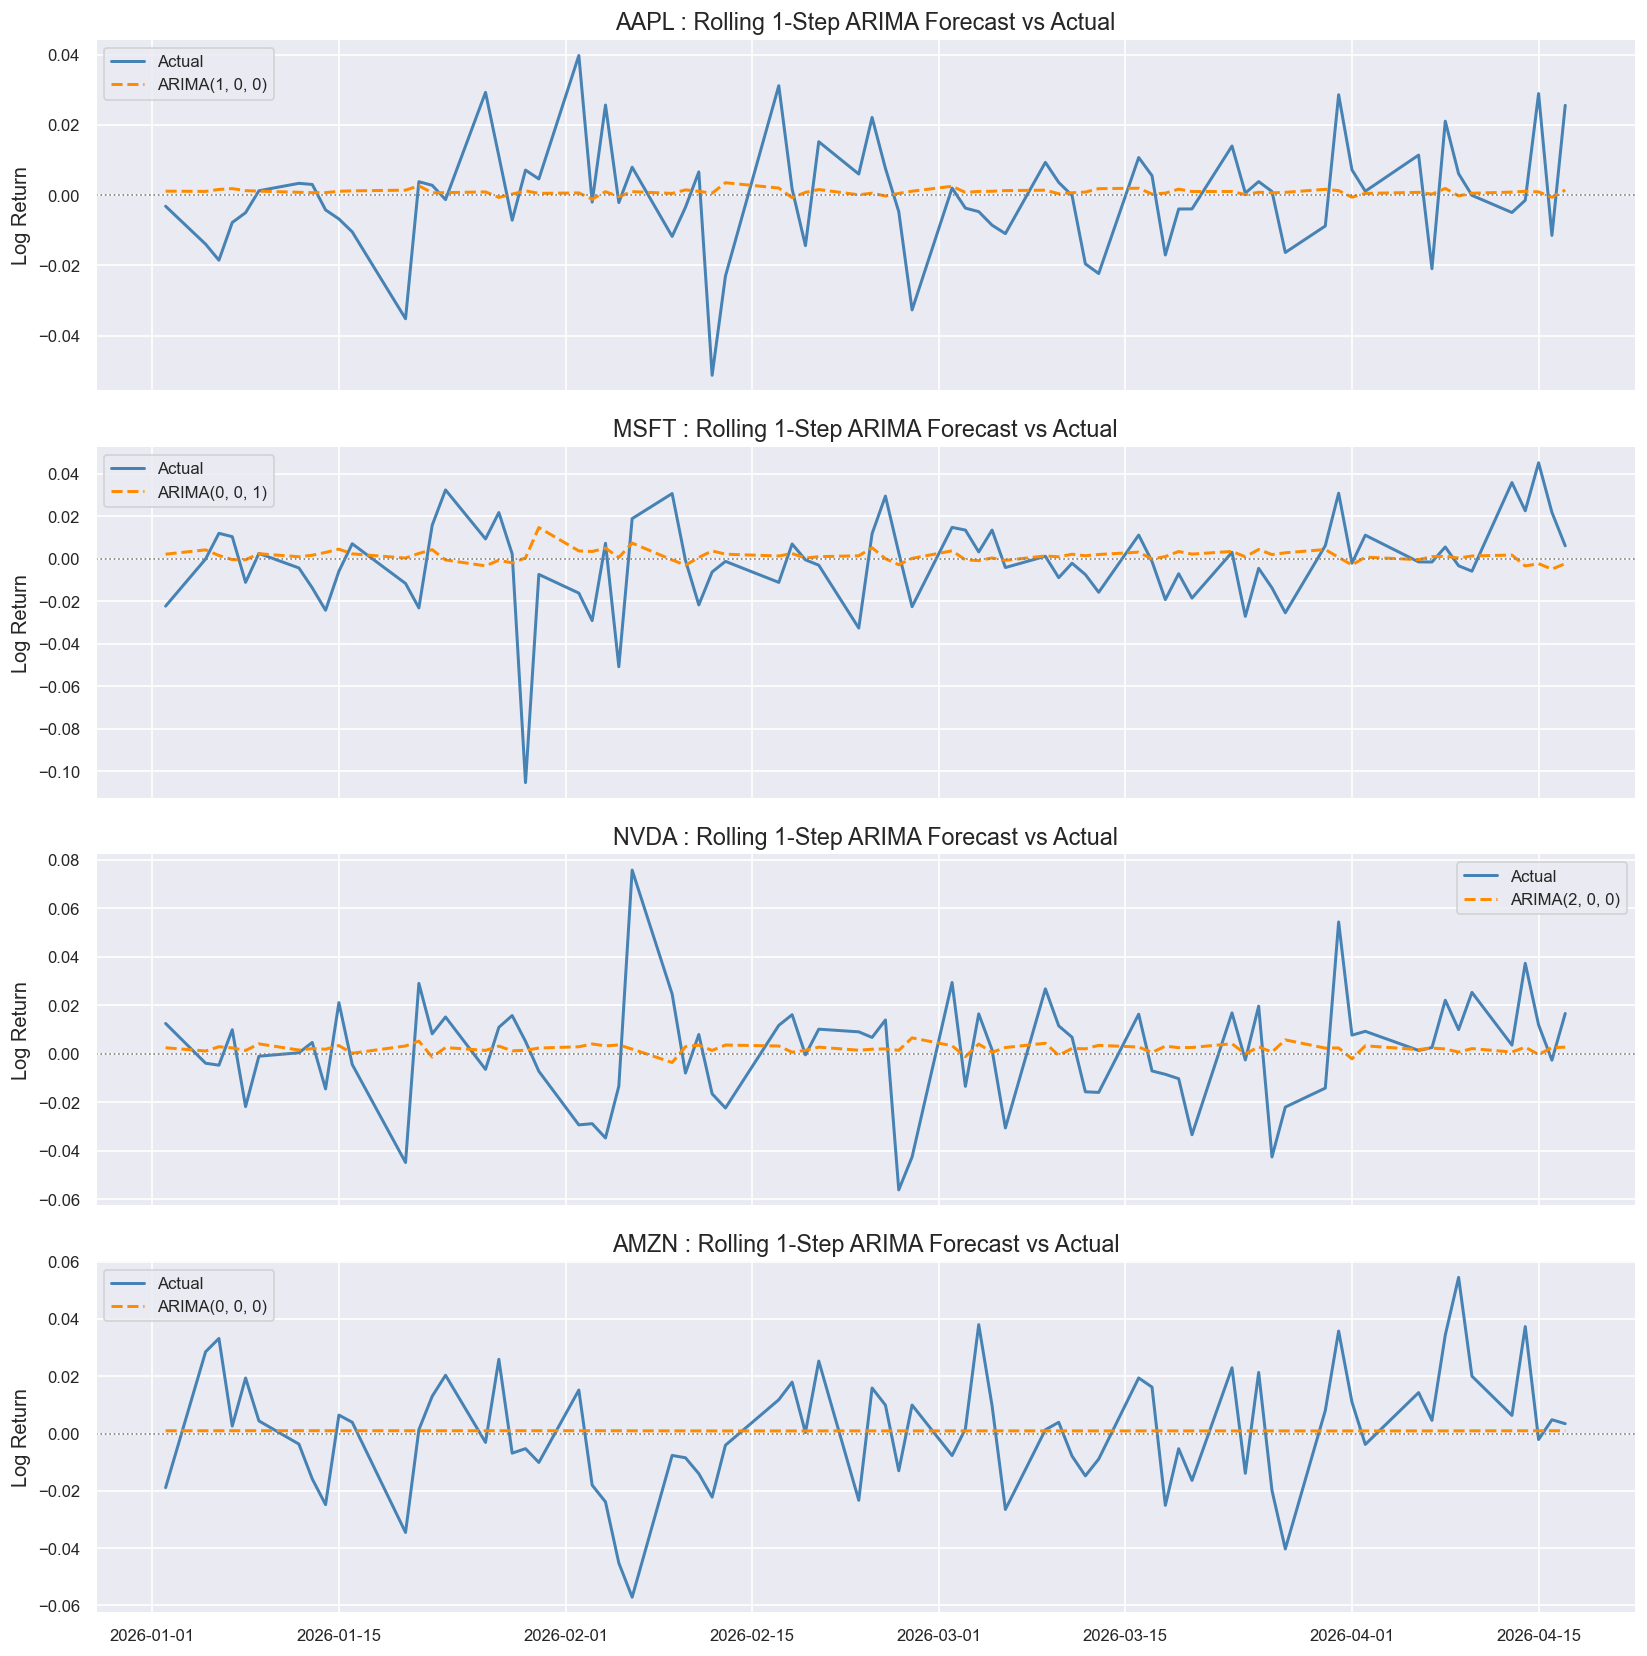

In [28]:
# Plotting actual vs ARIMA forecast

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, ticker in zip(axes, tickers):
    actual = log_returns_test[ticker].dropna()
    pred = arima_forecasts[ticker].reindex(actual.index)

    ax.plot(actual.index, actual, label="Actual", color="steelblue")
    ax.plot(pred.index, pred, label=f"ARIMA{best_orders[ticker]}", color="darkorange", linestyle="--")
    ax.axhline(0, color="gray", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker} : Rolling 1-Step ARIMA Forecast vs Actual")
    ax.set_ylabel("Log Return")
    ax.legend()

plt.tight_layout()
plt.show()

**Results & Interpretation:**

Across all stocks, ARIMA forecasts produced low RMSE and MAE values, but performance was very similar to the zero-return baseline. This suggests that the model provides only marginal predictive improvement.

From the plots, ARIMA predictions remain close to zero and much smoother than actual returns, failing to capture large spikes and volatility. This reflects the well-known property that daily stock returns are highly noisy and weakly predictable.

The ARIMA(0,0,0) model for AMZN indicates that its daily returns behave like white noise, with no significant autocorrelation structure. As a result, the optimal forecast is simply the mean (approximately zero), producing a flat prediction line.

The results confirm that while ARIMA can model basic structure, it has limited forecasting power for daily stock returns due to their near-random behavior.

## Section 9 - Time-Series Forecasting: XGBoost

**Goal:** Unlike ARIMA, which is purely linear, XGBoost (Gradient Boosted Trees) can capture complex, non-linear relationships in the data. We want to see if a modern ML approach can "beat" the traditional statistical model.

**Process:** We created "features" (like lagged returns from previous days) and train the XGBoost regressor to predict the next day's return.

In [29]:
# Building simple lag features (lag 1 to 5 of own stock returns)
SEED = 42
xgb_forecasts = {}

for ticker in tickers:
    # Create lag features from training data
    df = log_returns_train[[ticker]].copy()
    for lag in range(1, 6):
        df[f"lag{lag}"] = df[ticker].shift(lag)
    df = df.dropna()

    X_train = df.drop(columns=[ticker])
    y_train = df[ticker]

    # Fitting XGBoost model
    model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                              random_state=SEED, verbosity=0)
    model.fit(X_train, y_train)

    # Building test features using last 5 training values as starting lags
    history = list(log_returns_train[ticker].values)
    predictions = []

    for t in range(len(log_returns_test)):
        lags = history[-5:][::-1]  # lag1, lag2, ..., lag5
        pred = model.predict([lags])[0]
        predictions.append(pred)
        history.append(log_returns_test[ticker].iloc[t])

    xgb_forecasts[ticker] = pd.Series(predictions, index=log_returns_test.index)
    print(f"{ticker}: done")

AAPL: done
MSFT: done
NVDA: done
AMZN: done


In [30]:
# Evaluating XGBoost forecasts
print("XGBoost Forecast Errors (Test Set 2026)\n")

for ticker in tickers:
    actual   = log_returns_test[ticker]
    forecast = xgb_forecasts[ticker]
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    print(f"{ticker}:  RMSE = {rmse:.6f}  |  MAE = {mae:.6f}")

XGBoost Forecast Errors (Test Set 2026)

AAPL:  RMSE = 0.015986  |  MAE = 0.011610
MSFT:  RMSE = 0.022491  |  MAE = 0.015807
NVDA:  RMSE = 0.022329  |  MAE = 0.016987
AMZN:  RMSE = 0.021121  |  MAE = 0.016392


In [31]:
# Comparing ARIMA vs XGBoost side by side
print("Model Comparison — RMSE on 2026 Test Set\n")
print(f"{'Ticker':<8} {'ARIMA RMSE':>12} {'XGBoost RMSE':>14}")
print("-" * 36)

for ticker in tickers:
    actual = log_returns_test[ticker]
    rmse_arima = np.sqrt(mean_squared_error(actual, arima_forecasts[ticker]))
    rmse_xgb   = np.sqrt(mean_squared_error(actual, xgb_forecasts[ticker]))
    print(f"{ticker:<8} {rmse_arima:>12.6f} {rmse_xgb:>14.6f}")

Model Comparison — RMSE on 2026 Test Set

Ticker     ARIMA RMSE   XGBoost RMSE
------------------------------------
AAPL         0.015672       0.015986
MSFT         0.021883       0.022491
NVDA         0.022393       0.022329
AMZN         0.020571       0.021121


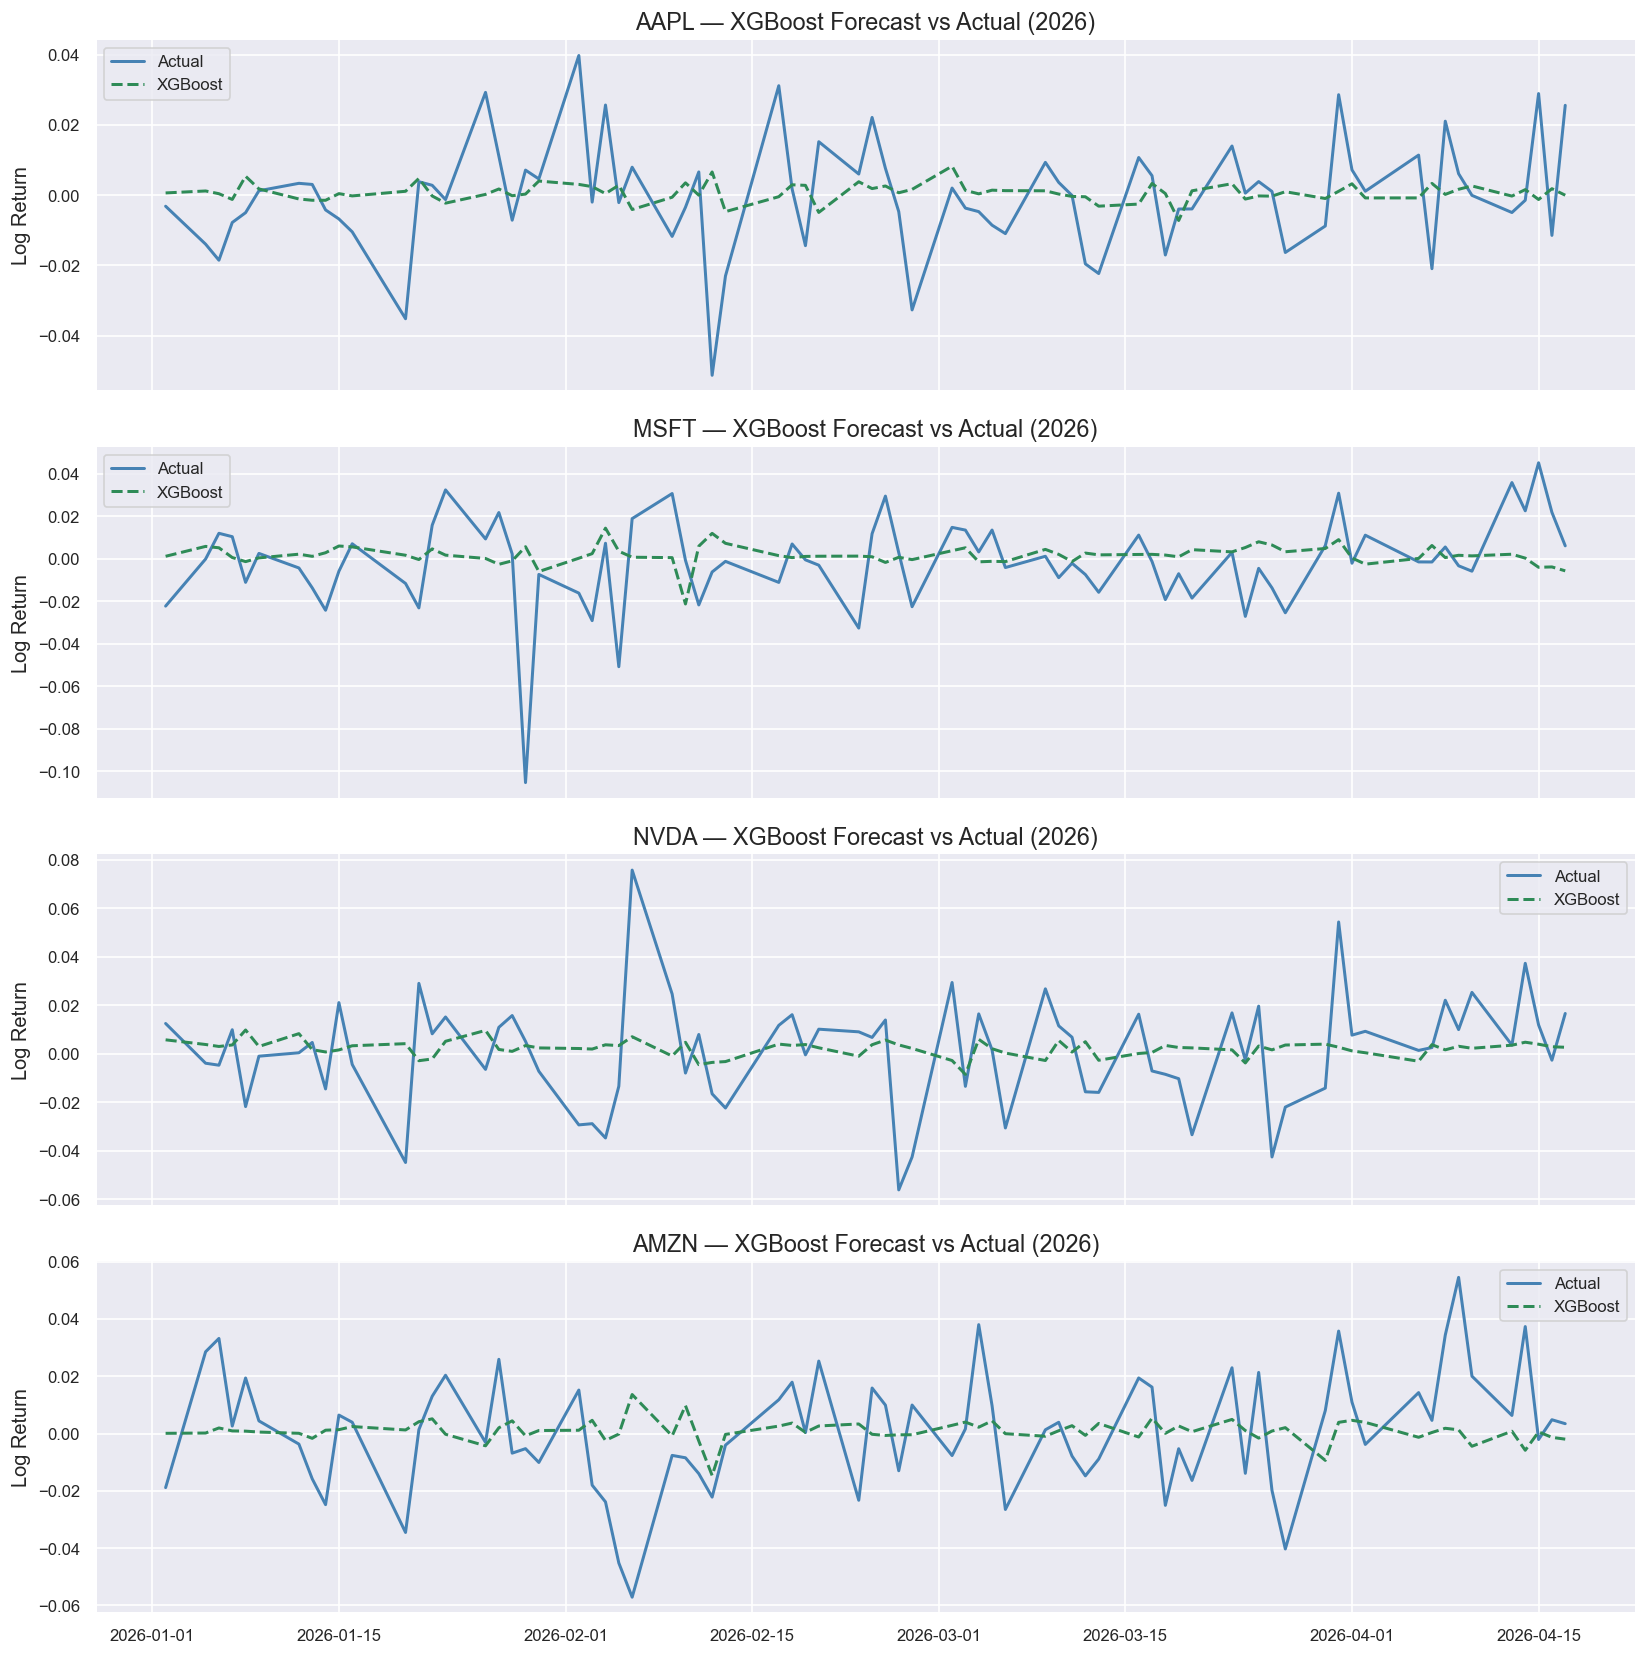

In [32]:
# Plotting actual vs XGBoost forecast
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(log_returns_test.index, log_returns_test[ticker], label="Actual",   color="steelblue")
    ax.plot(log_returns_test.index, xgb_forecasts[ticker],    label="XGBoost",  color="seagreen", linestyle="--")
    ax.set_title(f"{ticker} — XGBoost Forecast vs Actual (2026)")
    ax.set_ylabel("Log Return")
    ax.legend()

plt.tight_layout()
plt.show()

**Results & Interpretation:**

XGBoost captures slightly more variation than ARIMA but does not meaningfully improve forecasting accuracy due to the inherently noisy nature of stock returns. 

From the plots, XGBoost forecasts show more variation than ARIMA and attempt to capture short-term movements, but still remain close to zero and fail to capture large spikes in returns. This suggests that while the model can learn some nonlinear patterns, these patterns are weak in daily stock return data.

Overall, the performance difference between XGBoost and ARIMA is minimal.

## Section 10 - Conclusions

### 10.1 - Co-movement Summary

All four stocks are strongly correlated with each other. Pairwise correlations range from **0.52 (NVDA–AMZN)** to **0.67 (AAPL–MSFT)**, and the multiple regressions in Section 7 showed R² values between 0.42 and 0.60 when predicting one stock from the other three.

This means these stocks tend to go up and down together. They are all large U.S. tech companies affected by the same market conditions - interest rate changes, economic news, and sector-wide trends like the AI boom.

### 10.2 - Market Concentration Risk

Because all four stocks are so correlated, holding all of them does not provide much real diversification. During market downturns like the **COVID crash in March 2020** and the **2022 interest rate hikes**, all four stocks fell sharply at the same time; the exact opposite of what diversification is supposed to do.

A tech-heavy portfolio essentially becomes a single bet on the technology sector. To reduce concentration risk, a portfolio manager would need to add assets that are less correlated with tech, such as bonds, commodities, or international stocks.

### 10.3 - Forecasting Conclusions

Both ARIMA and XGBoost struggled to predict daily log returns for the 2026 test period. RMSE values were close to each stock's own standard deviation, meaning neither model was significantly better than just predicting zero every day.

This is consistent with the idea that stock markets are fairly efficient, for large, heavily-traded companies like AAPL, MSFT, NVDA, and AMZN, there is little predictable pattern left in daily returns after so many analysts and algorithms are already trading on the same information.

XGBoost slightly outperformed ARIMA in some cases, but the difference was not large enough to be practically useful.

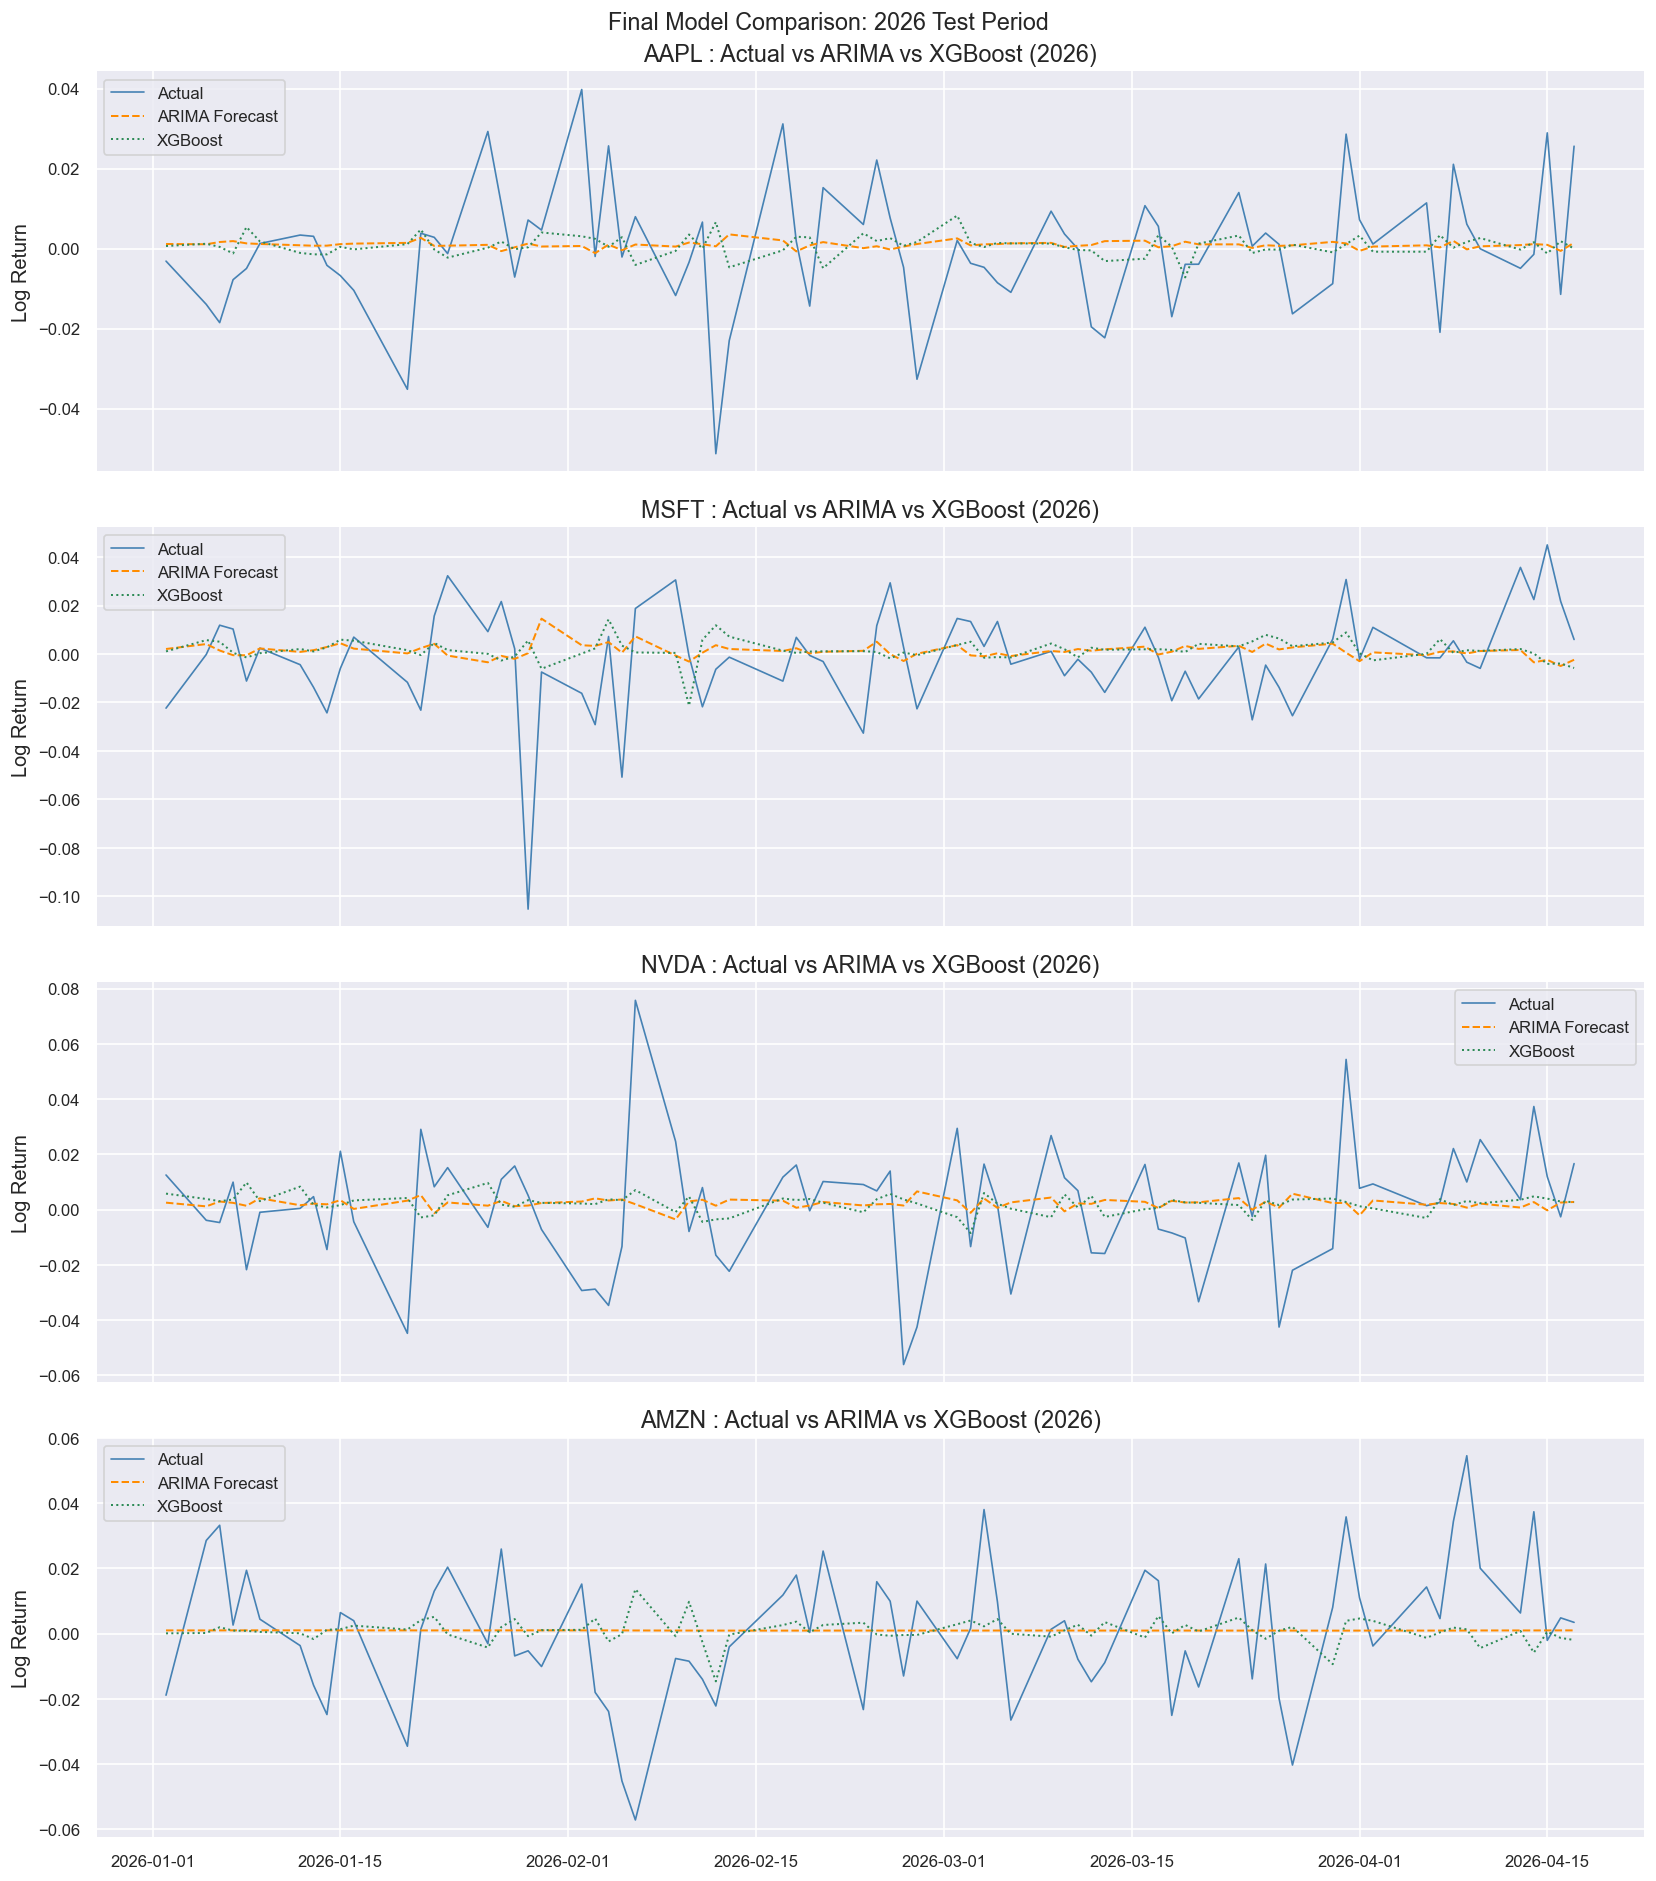

In [33]:
# Comparison — 2026 actual vs both forecasts for all stocks
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(log_returns_test.index, log_returns_test[ticker], label="Actual",        color="steelblue",  linewidth=1.0)
    ax.plot(log_returns_test.index, arima_forecasts[ticker],  label="ARIMA Forecast",color="darkorange",  linewidth=1.2, linestyle="--")
    ax.plot(log_returns_test.index, xgb_forecasts[ticker],    label="XGBoost",       color="seagreen",    linewidth=1.2, linestyle=":")
    ax.set_title(f"{ticker} : Actual vs ARIMA vs XGBoost (2026)")
    ax.set_ylabel("Log Return")
    ax.legend()

plt.suptitle("Final Model Comparison: 2026 Test Period", fontsize=14)
plt.tight_layout()
plt.show()

## Section 11 - Comparative Analysis with Related Cases


## Wang & Guo (2020)
### Similarities
Both this study and Wang and Guo apply ARIMA and XGBoost to financial time series data with the shared recognition that linear statistical models alone cannot fully capture stock market behavior. The feature engineering logic runs parallel in both: lagged return values are constructed, a training window is established, ARIMA is fitted to capture autocorrelation structure in the return series, and XGBoost is brought in to model the nonlinear lag relationships that ARIMA leaves on the table. The underlying intuition driving both studies is identical: pair a classical time series model with a gradient boosting algorithm, evaluate on a held-out test period, and measure performance using RMSE and MAE.

### Differences
The critical divergence is in what each study is trying to accomplish with those models. Wang and Guo engineer a hybrid system where ARIMA residuals are fed directly into XGBoost as corrective features, combining the two into a single forecasting machine optimized for maximum predictive accuracy. This study keeps the models entirely separate, running them as independent benchmarks against each other and against a zero-return baseline. This is not a limitation but a deliberate design choice that serves a different goal. Wang and Guo ask "how accurately can we forecast?" while this study asks "what does forecast accuracy reveal about market efficiency and the co-movement of these stocks?" That distinction reframes the weaker forecasting numbers as a finding rather than a failure: the near-random performance of both models is itself evidence that AAPL, MSFT, NVDA, and AMZN are efficiently priced and that their shared movement is driven by macro forces no lag-based model can anticipate. Additionally, Wang and Guo operate at the aggregate market level using Chinese stock market index data, whereas this study works at the individual stock level across four of the most traded U.S. technology companies. That granularity makes the findings of this study more directly actionable for investors making specific portfolio construction decisions.

## Bhowmik (2023)
Bhowmik (2023) conducted a risk and return analysis of FAANG (Facebook, Apple, Amazon, Netflix, and Google) stocks over a period of 10 years (December 2012 to May 2023). Similar to our project, this study uses yfinance via the pandas library in Python to extract stock data. Bhowmik's study examined monthly returns, whereas ours focused on daily log returns for tech stocks. In our project, we computed pairwise correlations between the tech stocks; however, in his study, Bhowmik correlated each stock's returns with the broader S&P market index. Our correlation analysis shows that tech stocks tend to move together, offering investors less diversification, while Bhowmik's analysis shows that tech stocks move strongly with the overall market. Thus, tech investors need to take into account both broad market movements and co-movements within the tech sector. Bhowmik's study is relevant to our project because it includes portfolio risk analysis and the construction of different portfolios to demonstrate which asset combinations offer better risk-adjusted returns. This is a valuable direction for extending our research in the future.

## Section 12 - References

Bhowmik, M. (2023). *Risk and return analysis using FAANG stocks*. Medium. https://medium.com/@manisangsu/risk-and-return-analysis-using-faang-stocks-d0dc1026a416

Wang, Y., & Guo, Y. (2020). Forecasting method of stock market volatility in time series data based on mixed model of ARIMA and XGBoost. *China Communications*, *17*(3), 205–221.